# Functional connectivity analysis

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Settings
data_dir = '/DATAPOOL/VPMB/BIDS-VPMB-SPE'
#data_dir = '/home/alexandresayal/mnt/DATAPOOL/VPMB/BIDS-VPMB-SPE'
tc_dir = os.path.join(data_dir,'derivatives','timecourses')
output_dir = os.path.join(data_dir,'derivatives','feedbackSimulator')

subject_list = [x for x in os.listdir(data_dir) if 'sub-' in x]
subject_list.sort()

tr_list = [0.5, 0.75, 1, 2.5]
n_volumes_list = [780, 520, 390, 156]
run_list = ['UA']
hrf_delay = 0 # in seconds
roi_list = ['left_mt','right_mt','left_v1','right_v1']

In [3]:
# Load each timecourse from npy files in tc_dir
# split them into the four ROIs (left_mt, right_mt, left_v1, right_v1)
# and save them in a dataframe with the following columns: subject, tr, run, left_mt, right_mt, left_v1, right_v1, bilateral_mt, bilateral_v1

df = pd.DataFrame(columns=['subject','tr','run','left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1'])

for ss,subject in enumerate(subject_list):
    for tt,tr in enumerate(tr_list):
        for rr,run in enumerate(run_list):
            # load timecourse
            tc_file = os.path.join(tc_dir,f"{subject}_{tr}_{run}_hp_std-zscoresample_ss.npy")
            tc = np.load(tc_file)

            # estimate mean of first and last two rois (creating bilateral_mt and bilateral_v1)
            tc_mean1 = np.mean(tc[:,0:2], axis=1)
            tc_mean2 = np.mean(tc[:,2:4], axis=1)

            # add row to dataframe
            df.loc[len(df)] = [subject, tr, run, tc[:,0], tc[:,1], tc[:,2], tc[:,3], tc_mean1, tc_mean2]    

roi_list = ['left_mt','right_mt','left_v1','right_v1','bilateral_mt','bilateral_v1']

In [36]:
6/2.5

2.4

Text(0, 0.5, 'Correlation')

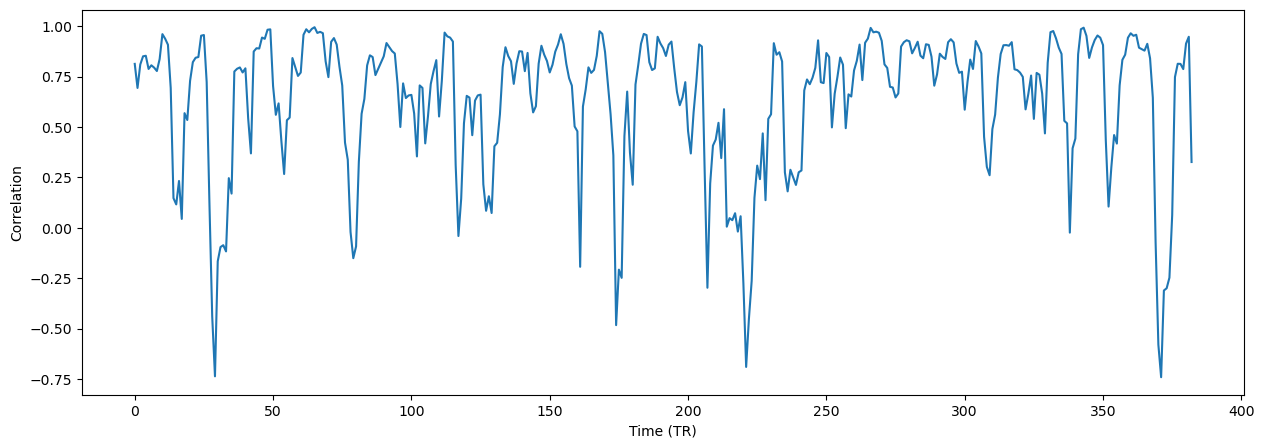

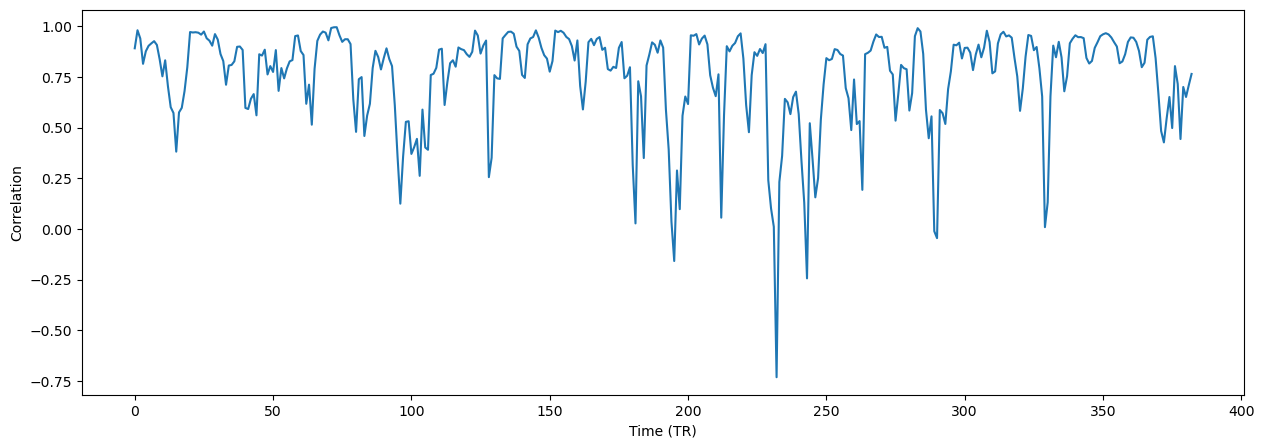

In [40]:
# Estimate the correlation between the timecourses of left and right v1 and mt considering a sliding window of 6 seconds

# Settings
sub_idx = 1
tr_idx = 2
window_size = 7.5 # in seconds
window_size_tr = int(window_size/tr_list[tr_idx])
#step_size = tr_list[tr_idx] # in seconds
step_size_tr = 1

# Get timecourse
tc = df.loc[(df['subject']==subject_list[sub_idx]) & (df['tr']==tr_list[tr_idx]) & (df['run']==run_list[0])][roi_list].values
n_volumes = tc[0,0].shape[0]

# Estimate correlation
corr = np.zeros((len(roi_list),len(roi_list),int((n_volumes-window_size_tr)/step_size_tr)))

for ii in range(len(roi_list)):
    for jj in range(len(roi_list)):
        for kk in range(int((n_volumes-window_size_tr)/step_size_tr)):
            corr[ii,jj,kk] = np.corrcoef(tc[0,ii][kk*step_size_tr:kk*step_size_tr+window_size_tr],tc[0,jj][kk*step_size_tr:kk*step_size_tr+window_size_tr])[0,1]

# Plot left mt - right mt correlation
plt.figure(figsize=(15,5))
plt.plot(corr[0,1,:])
plt.xlabel('Time (TR)')
plt.ylabel('Correlation')

# Plot left v1 - right v1 correlation
plt.figure(figsize=(15,5))
plt.plot(corr[2,3,:])
plt.xlabel('Time (TR)')
plt.ylabel('Correlation')



In [19]:
tc[0,1][:10]

array([-0.43873116, -1.0981828 , -1.5963974 ,  0.18762551, -0.6584161 ,
        0.35181805, -0.18466546,  0.4993037 , -0.01673917,  0.28444389],
      dtype=float32)